In [2]:
# Install necessary libraries
!pip install catboost lightgbm xgboost shap scikit-optimize

In [29]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.ensemble import ExtraTreesRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, RegressorMixin
import shap

In [19]:
# Load and preprocess the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

# Define features and target variable
numeric_features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
                    'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour']
categorical_features = ['vessel_type']

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Sparse=False for better compatibility
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

<ipython-input-19-3c47667fdeba>:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


In [20]:
# Define features and target variable
X = data[numeric_features + categorical_features]
y = data['TravelTime_seconds']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [14]:
# Hyperparameter Tuning for Extra Trees
et_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

et_model = ExtraTreesRegressor(random_state=42)
et_grid_search = BayesSearchCV(et_model, et_param_grid, cv=5, scoring='neg_mean_squared_error', n_iter=10, random_state=42)
et_grid_search.fit(X_train, y_train)
best_et_model = et_grid_search.best_estimator_
et_y_pred = best_et_model.predict(X_test)

print("Best Hyperparameters for Extra Trees:")
print(et_grid_search.best_params_)

/usr/local/lib/python3.10/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [100, 200] was inferred to Integer(low=100, high=200, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(100, 200), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [2, 5] was inferred to Integer(low=2, high=5, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(2, 5), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [1, 2] was inferred to Integer(low=1, high=2, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred 

Best Hyperparameters for Extra Trees:
OrderedDict([('max_depth', None), ('min_samples_leaf', 1), ('min_samples_split', 4), ('n_estimators', 180)])


In [15]:
# Hyperparameter Tuning for LightGBM
lgb_param_grid = {
    'num_leaves': Integer(32, 64),  # Integer range for num_leaves
    'max_depth': Integer(5, 10),    # Integer range for max_depth
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),  # Log-uniform range for learning_rate
    'n_estimators': Integer(100, 200)  # Integer range for n_estimators
}

lgb_model = LGBMRegressor(random_state=42)
lgb_bayes_search = BayesSearchCV(lgb_model, lgb_param_grid, n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
lgb_bayes_search.fit(X_train, y_train)
best_lgb_model = lgb_bayes_search.best_estimator_
lgb_y_pred = best_lgb_model.predict(X_test)

print("Best Hyperparameters for LightGBM:")
print(lgb_bayes_search.best_params_)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001838 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2565
[LightGBM] [Info] Number of data points in the train set: 15015, number of used features: 16
[LightGBM] [Info] Start training from score 313731.456210
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [21]:
# Create meta-features from base model predictions
meta_features = pd.DataFrame({'ExtraTrees': et_y_pred, 'LightGBM': lgb_y_pred})

# Custom wrapper for XGBRegressor to fix compatibility with BayesSearchCV
class CustomXGBRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, learning_rate=0.1, n_estimators=100, max_depth=3, subsample=1.0, random_state=42):
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.subsample = subsample
        self.random_state = random_state
        self.model = XGBRegressor(
            objective='reg:squarederror',
            learning_rate=self.learning_rate,
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            subsample=self.subsample,
            random_state=self.random_state
        )

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_params(self, deep=True):
        return {
            'learning_rate': self.learning_rate,
            'n_estimators': self.n_estimators,
            'max_depth': self.max_depth,
            'subsample': self.subsample,
            'random_state': self.random_state
        }

    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        self.model = XGBRegressor(
            objective='reg:squarederror',
            learning_rate=self.learning_rate,
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            subsample=self.subsample,
            random_state=self.random_state
        )
        return self

# Define the hyperparameter search space for XGBoost
xgb_param_grid = {
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),  # Log-uniform range for learning_rate
    'n_estimators': Integer(100, 200),  # Integer range for n_estimators
    'max_depth': Integer(3, 5),  # Integer range for max_depth
    'subsample': Real(0.8, 1.0)  # Continuous range for subsample
}

# Initialize the custom XGBoost model
xgb_model = CustomXGBRegressor(random_state=42)

# Initialize BayesSearchCV
xgb_bayes_search = BayesSearchCV(
    xgb_model,
    xgb_param_grid,
    n_iter=20,  # Number of iterations
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Scoring metric
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit the BayesSearchCV to the meta-features
xgb_bayes_search.fit(meta_features, y_test)

# Get the best model and its hyperparameters
best_xgb_model = xgb_bayes_search.best_estimator_
xgb_y_pred = best_xgb_model.predict(meta_features)

# Print the best hyperparameters
print("Best Hyperparameters for XGBoost Meta-Learner:")
print(xgb_bayes_search.best_params_)

Best Hyperparameters for XGBoost Meta-Learner:
OrderedDict([('learning_rate', 0.03577671705280306), ('max_depth', 4), ('n_estimators', 200), ('subsample', 0.976585776872059)])


In [22]:
# Train the best XGBoost model on meta-features
best_xgb_model.fit(meta_features, y_test)

# Evaluate stacking ensemble performance
final_predictions = best_xgb_model.predict(meta_features)
ensemble_mae = mean_absolute_error(y_test, final_predictions)
ensemble_mse = mean_squared_error(y_test, final_predictions)
ensemble_r2 = r2_score(y_test, final_predictions)

print("Stacking Ensemble (XGBoost Meta-Learner):")
print("Mean Absolute Error:", ensemble_mae)
print("Mean Squared Error:", ensemble_mse)
print("R-squared:", ensemble_r2)

Stacking Ensemble (XGBoost Meta-Learner):
Mean Absolute Error: 3353.107456213372
Mean Squared Error: 179195772.46721742
R-squared: 0.9986767779097813


In [23]:
# Cross-validation for XGBoost Meta-Learner
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'neg_mean_squared_error': 'neg_mean_squared_error',
           'neg_mean_absolute_error': 'neg_mean_absolute_error',
           'r2': 'r2'}
cv_results_xgb = cross_validate(best_xgb_model, meta_features, y_test, cv=kf, scoring=scoring)
print("XGBoost Meta-learner cross-validation results:")
print("Mean MAE:", -cv_results_xgb['test_neg_mean_absolute_error'].mean())
print("Mean MSE:", -cv_results_xgb['test_neg_mean_squared_error'].mean())
print("Mean R2:", cv_results_xgb['test_r2'].mean())

XGBoost Meta-learner cross-validation results:
Mean MAE: 3932.4677664835776
Mean MSE: 249640958.73718423
Mean R2: 0.9981336953897912


In [24]:
# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Compute MAPE for the Stacking Model
stacking_mape = mean_absolute_percentage_error(y_test, final_predictions)
print(f"Stacking Ensemble (XGBoost Meta-Learner) MAPE: {stacking_mape:.2f}%")

# Compute MAPE for individual models
et_mape = mean_absolute_percentage_error(y_test, et_y_pred)
lgb_mape = mean_absolute_percentage_error(y_test, lgb_y_pred)

print(f"Extra Trees Regressor MAPE: {et_mape:.2f}%")
print(f"LightGBM Regressor MAPE: {lgb_mape:.2f}%")

Stacking Ensemble (XGBoost Meta-Learner) MAPE: 0.58%
Extra Trees Regressor MAPE: 0.44%
LightGBM Regressor MAPE: 1.33%


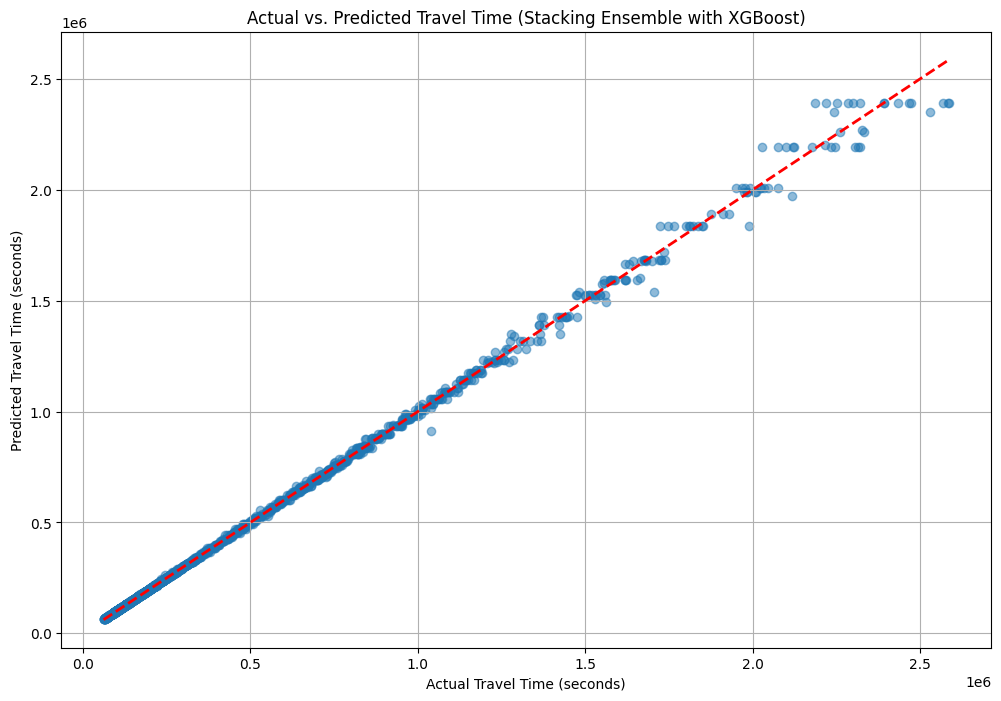

In [25]:

# Plot Actual vs. Predicted
plt.figure(figsize=(12, 8))
plt.scatter(y_test, final_predictions, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.title('Actual vs. Predicted Travel Time (Stacking Ensemble with XGBoost)')
plt.xlabel('Actual Travel Time (seconds)')
plt.ylabel('Predicted Travel Time (seconds)')
plt.grid(True)
plt.show()

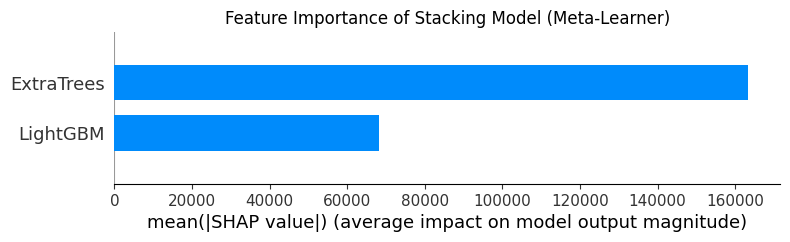

In [33]:
# Function to compute feature importance of the stacking model
def compute_feature_importance(meta_model, meta_features):

    # Extract the underlying XGBRegressor model from the custom wrapper
    xgb_model = meta_model.model

    # Create a SHAP explainer for the XGBoost model
    explainer = shap.TreeExplainer(xgb_model)

    # Compute SHAP values for the meta-features
    shap_values = explainer.shap_values(meta_features)

    # Plot the feature importance using SHAP summary plot
    shap.summary_plot(shap_values, meta_features, plot_type="bar", show=False)

    # Add a title to the plot
    plt.title("Feature Importance of Stacking Model (Meta-Learner)")
    plt.show()

# Compute and visualize feature importance for the stacking model
compute_feature_importance(best_xgb_model, meta_features)

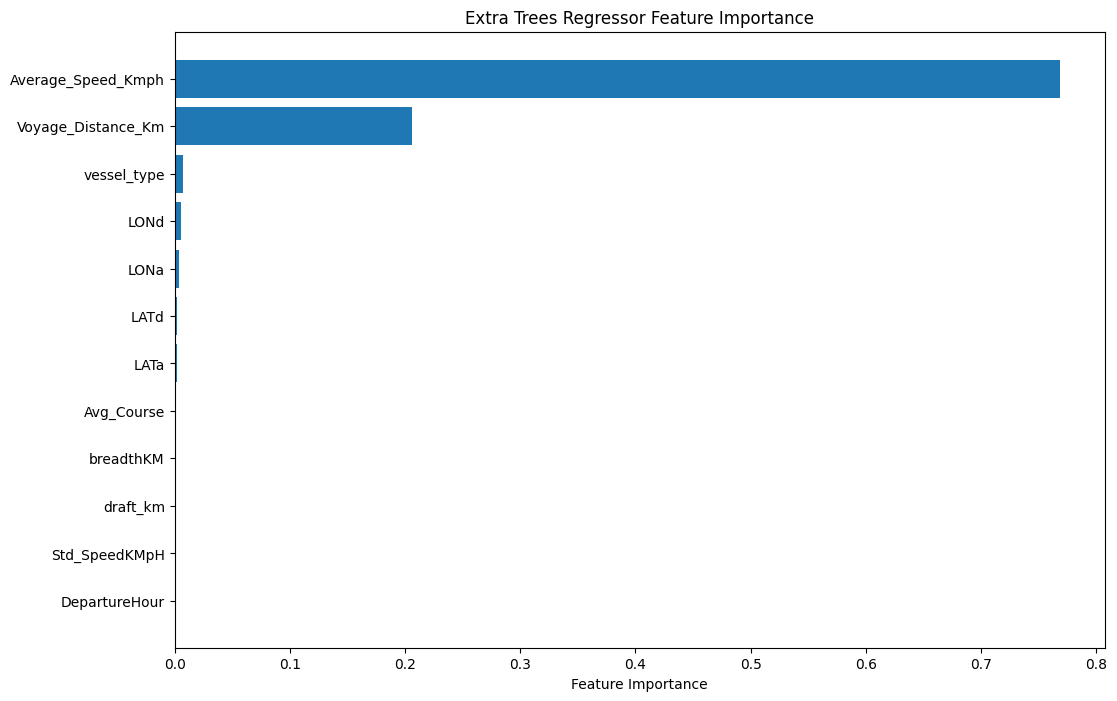

In [26]:
# Feature Importance for Extra Trees Model
et_feature_importance = best_et_model.feature_importances_
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))

# Aggregate importance for 'vessel_type' (categorical feature)
vessel_type_importance = 0
vessel_type_indices = [i for i, name in enumerate(feature_names) if name.startswith('vessel_type_')]

# Sum the importance of all one-hot encoded columns for 'vessel_type'
for idx in vessel_type_indices:
    vessel_type_importance += et_feature_importance[idx]

# Remove individual one-hot encoded columns from feature_names and feature_importances
feature_names_aggregated = [name for name in feature_names if not name.startswith('vessel_type_')]
feature_importances_aggregated = [importance for i, importance in enumerate(et_feature_importance) if i not in vessel_type_indices]

# Add aggregated 'vessel_type' importance
feature_names_aggregated.append('vessel_type')
feature_importances_aggregated.append(vessel_type_importance)

# Sort feature importance in ascending order
sorted_idx = np.argsort(feature_importances_aggregated)  # Remove [::-1] for ascending order

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_idx)), np.array(feature_importances_aggregated)[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(feature_names_aggregated)[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Extra Trees Regressor Feature Importance')
plt.show()

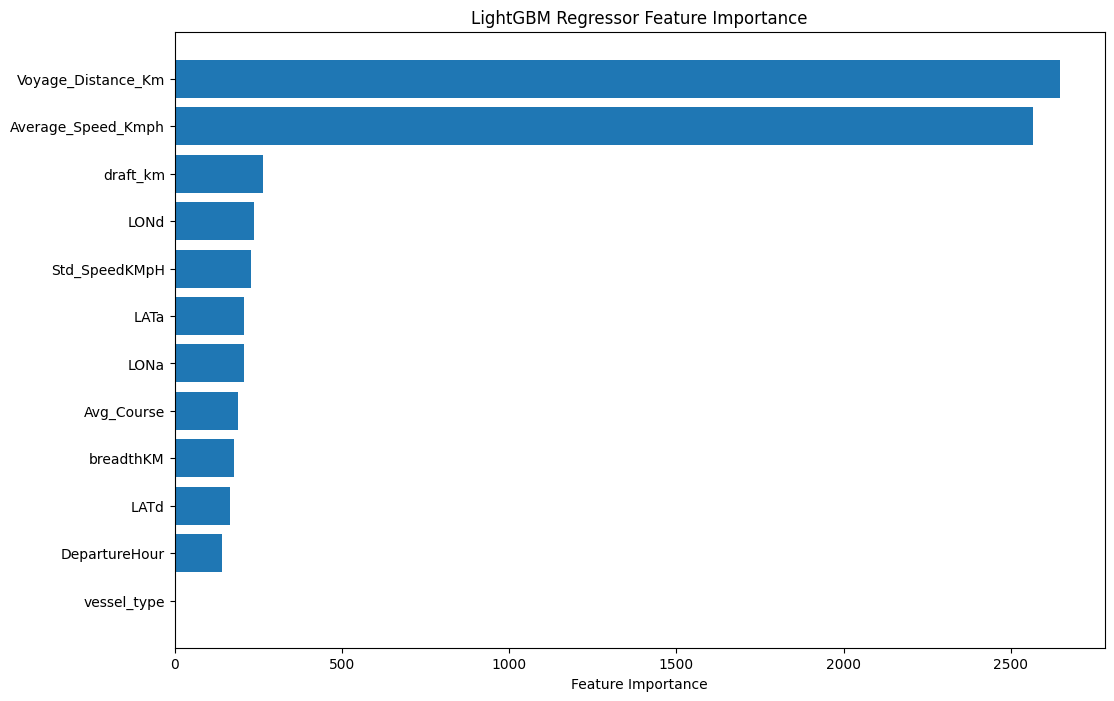

In [27]:
# Feature Importance for LightGBM Model
lgb_feature_importance = best_lgb_model.feature_importances_
feature_names_aggregated = [name for name in feature_names if not name.startswith('vessel_type_')]
feature_importances_aggregated = [importance for i, importance in enumerate(lgb_feature_importance) if i not in vessel_type_indices]

# Add aggregated 'vessel_type' importance
feature_names_aggregated.append('vessel_type')
feature_importances_aggregated.append(vessel_type_importance)

# Sort feature importance in ascending order
sorted_idx = np.argsort(feature_importances_aggregated)  # Remove [::-1] for ascending order

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_idx)), np.array(feature_importances_aggregated)[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(feature_names_aggregated)[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('LightGBM Regressor Feature Importance')
plt.show()